Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [3]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [4]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

FD_df = pd.DataFrame(training_data_FD)
kbg_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([FD_df,kbg_df])

inv_mass = full_data["inv_mass"].values


In [6]:
print(len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))

#ratio background signal

810.3201663201663


In [7]:


#leave out inv_mass and pt
features = [c for c in full_data.columns 
            if c not in ["inv_mass", "pt_cand", "species"]]

x_data = full_data[features]
y_data = full_data['species']
print(set(y_data))

# stratify to ensure: fraction signal / background in train is approx. fraction signal / background in test
# if for example x_test[10] is selected, then : y_test[10] the label, and m_test[10] the invariant mass of event
x_train_full, x_test, y_train_full, y_test, m_train, m_test = train_test_split(
    x_data,
    y_data,
    inv_mass,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)


print(np.unique(y_train_full, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.

pos_class_weight = (len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))




{0.0, 1.0}
(array([0., 1.]), array([3741734,    4618]))


In [8]:
train_x, val_x, train_y, val_y, m_train, m_val = train_test_split(x_train_full, y_train_full, m_train, test_size=0.2, random_state=42, stratify=y_train_full)
dtrain = xgb.DMatrix(train_x, label=train_y)
dval = xgb.DMatrix(val_x, label=val_y)




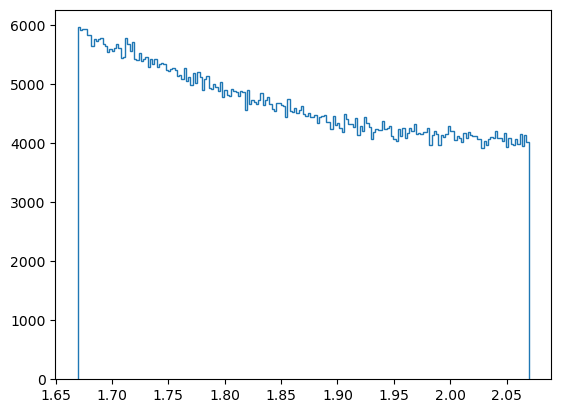

In [9]:
plt.hist(m_test[y_test==0], bins=200, histtype="step", label="Bkg (no cut)")
plt.show()

In [10]:
import optuna
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import average_precision_score


from optuna.integration import XGBoostPruningCallback
import xgboost as xgb

# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.

#In HEP: fixed validation set is crucial, so: splitting data outside the loop.



def objective(trial):

   
    params = {
        "verbosity": 0,
       
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),

        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        # scale_pos_weight tune (not reccomended):
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", (pos_class_weight*0.9), (pos_class_weight*1.1))
        

        "scale_pos_weight": pos_class_weight,  # fixed class weight
        "reg_alpha": trial.suggest_float("reg_alpha", 5.0, 30.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 50.0, 200.0, log=True),
    
       # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.01, 10.0, log=True),

        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.5, log=True), #09
        "max_depth": trial.suggest_int("max_depth", 2, 6), 
        "subsample": trial.suggest_float("subsample", 0.3, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 0.9),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "max_delta_step": 1,
        "random_state": 42
    }
    num_boost_round = 1000 
    #params.update(base_params)
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-aucpr")
    bst = xgb.train(params, dtrain=dtrain, early_stopping_rounds=10, num_boost_round=num_boost_round, evals=[(dval, "validation")], callbacks=[pruning_callback])
    trial.set_user_attr('best_iteration', bst.best_iteration)

    scores = bst.predict(dval)

    
    y_true = val_y

    auc_val = average_precision_score(y_true, scores)


    trial.set_user_attr("val_aucpr", auc_val)


    return auc_val




if __name__ == "__main__":
    study = optuna.create_study(
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=15), direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=60)
    print("Best trial:")
    print(study.best_trial)



[I 2026-01-21 07:15:35,280] A new study created in memory with name: no-name-609f47a1-f23c-4881-b6f3-43cb25aa8c26


[0]	validation-aucpr:0.01004
[1]	validation-aucpr:0.03039
[2]	validation-aucpr:0.03046
[3]	validation-aucpr:0.03080
[4]	validation-aucpr:0.03075
[5]	validation-aucpr:0.05588
[6]	validation-aucpr:0.05586
[7]	validation-aucpr:0.05821
[8]	validation-aucpr:0.05906
[9]	validation-aucpr:0.05894
[10]	validation-aucpr:0.06753
[11]	validation-aucpr:0.06740
[12]	validation-aucpr:0.06732
[13]	validation-aucpr:0.06725
[14]	validation-aucpr:0.06755
[15]	validation-aucpr:0.06749
[16]	validation-aucpr:0.06774
[17]	validation-aucpr:0.06779
[18]	validation-aucpr:0.06780
[19]	validation-aucpr:0.06654
[20]	validation-aucpr:0.06649
[21]	validation-aucpr:0.06680
[22]	validation-aucpr:0.06676
[23]	validation-aucpr:0.06674
[24]	validation-aucpr:0.06671
[25]	validation-aucpr:0.06666
[26]	validation-aucpr:0.06660
[27]	validation-aucpr:0.06665
[28]	validation-aucpr:0.06659


[I 2026-01-21 07:15:46,493] Trial 0 finished with value: 0.06403964542027103 and parameters: {'n_estimators': 624, 'min_child_weight': 48, 'reg_alpha': 18.55974501953827, 'reg_lambda': 114.65640647739862, 'gamma': 0.02938027938703535, 'learning_rate': 0.0026364803038431655, 'max_depth': 2, 'subsample': 0.8197056874649611, 'colsample_bytree': 0.5808920093945671}. Best is trial 0 with value: 0.06403964542027103.


[0]	validation-aucpr:0.00982
[1]	validation-aucpr:0.02969
[2]	validation-aucpr:0.03028
[3]	validation-aucpr:0.03028
[4]	validation-aucpr:0.03028
[5]	validation-aucpr:0.05777
[6]	validation-aucpr:0.05764
[7]	validation-aucpr:0.07326
[8]	validation-aucpr:0.07358
[9]	validation-aucpr:0.07349
[10]	validation-aucpr:0.08295
[11]	validation-aucpr:0.08287
[12]	validation-aucpr:0.08774
[13]	validation-aucpr:0.08756
[14]	validation-aucpr:0.08800
[15]	validation-aucpr:0.08801
[16]	validation-aucpr:0.08806
[17]	validation-aucpr:0.08795
[18]	validation-aucpr:0.08788
[19]	validation-aucpr:0.08752
[20]	validation-aucpr:0.08751
[21]	validation-aucpr:0.08748
[22]	validation-aucpr:0.08756
[23]	validation-aucpr:0.08751
[24]	validation-aucpr:0.08745
[25]	validation-aucpr:0.08747
[26]	validation-aucpr:0.08747


[I 2026-01-21 07:15:53,953] Trial 1 finished with value: 0.08451124069215248 and parameters: {'n_estimators': 1092, 'min_child_weight': 5, 'reg_alpha': 28.42539893932712, 'reg_lambda': 158.54421990210378, 'gamma': 0.04335281794951567, 'learning_rate': 0.003095566460242371, 'max_depth': 2, 'subsample': 0.4825453457757226, 'colsample_bytree': 0.5198051453057903}. Best is trial 1 with value: 0.08451124069215248.


...

[0]	validation-aucpr:0.01108
[1]	validation-aucpr:0.03410
[2]	validation-aucpr:0.03450
[3]	validation-aucpr:0.04096
[4]	validation-aucpr:0.04190
[5]	validation-aucpr:0.08209
[6]	validation-aucpr:0.08242
[7]	validation-aucpr:0.10187
[8]	validation-aucpr:0.10214
[9]	validation-aucpr:0.10216
[10]	validation-aucpr:0.11149
[11]	validation-aucpr:0.11179
[12]	validation-aucpr:0.11169
[13]	validation-aucpr:0.11199
[14]	validation-aucpr:0.11204


[I 2026-01-21 07:26:43,710] Trial 58 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01233
[1]	validation-aucpr:0.04834
[2]	validation-aucpr:0.05306
[3]	validation-aucpr:0.05720
[4]	validation-aucpr:0.05802
[5]	validation-aucpr:0.08111
[6]	validation-aucpr:0.08430
[7]	validation-aucpr:0.09481
[8]	validation-aucpr:0.10159
[9]	validation-aucpr:0.11110
[10]	validation-aucpr:0.13667
[11]	validation-aucpr:0.13933
[12]	validation-aucpr:0.15711
[13]	validation-aucpr:0.15822
[14]	validation-aucpr:0.19064


[I 2026-01-21 07:26:49,385] Trial 59 pruned. Trial was pruned at iteration 15.


Best trial:
FrozenTrial(number=9, state=<TrialState.COMPLETE: 1>, values=[0.33427173681292915], datetime_start=datetime.datetime(2026, 1, 21, 7, 17, 7, 762397), datetime_complete=datetime.datetime(2026, 1, 21, 7, 18, 9, 95440), params={'n_estimators': 973, 'min_child_weight': 20, 'reg_alpha': 5.603095362887918, 'reg_lambda': 76.94847518511574, 'gamma': 0.09452571391072308, 'learning_rate': 0.0931504999849916, 'max_depth': 5, 'subsample': 0.832327645545796, 'colsample_bytree': 0.4777719401295595}, user_attrs={'best_iteration': 144, 'val_aucpr': np.float64(0.33427173681292915)}, system_attrs={}, intermediate_values={0: 0.01341344316127373, 1: 0.04730144533557328, 2: 0.04978184976198009, 3: 0.05700733466317417, 4: 0.05712809699234384, 5: 0.0762651029374311, 6: 0.08035861757269352, 7: 0.09055878550623642, 8: 0.09585850401762741, 9: 0.0979939354166953, 10: 0.10249489420357061, 11: 0.1032116246612112, 12: 0.11027809890115514, 13: 0.11152659476925132, 14: 0.13686191614350335, 15: 0.1417252156

In [11]:
study.optimize(objective, n_trials=20)

[0]	validation-aucpr:0.01245
[1]	validation-aucpr:0.03834
[2]	validation-aucpr:0.04071
[3]	validation-aucpr:0.04153
[4]	validation-aucpr:0.04549
[5]	validation-aucpr:0.08596
[6]	validation-aucpr:0.08762
[7]	validation-aucpr:0.12669
[8]	validation-aucpr:0.13334
[9]	validation-aucpr:0.15533
[10]	validation-aucpr:0.16690
[11]	validation-aucpr:0.16979
[12]	validation-aucpr:0.19899
[13]	validation-aucpr:0.20967
[14]	validation-aucpr:0.23150


[I 2026-01-21 07:26:55,581] Trial 60 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01221
[1]	validation-aucpr:0.04259
[2]	validation-aucpr:0.05341
[3]	validation-aucpr:0.05005
[4]	validation-aucpr:0.05804
[5]	validation-aucpr:0.13143
[6]	validation-aucpr:0.15685
[7]	validation-aucpr:0.15926
[8]	validation-aucpr:0.17784
[9]	validation-aucpr:0.18578
[10]	validation-aucpr:0.21041
[11]	validation-aucpr:0.21842
[12]	validation-aucpr:0.22183
[13]	validation-aucpr:0.22683
[14]	validation-aucpr:0.22733


[I 2026-01-21 07:27:01,040] Trial 61 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01326
[1]	validation-aucpr:0.04780
[2]	validation-aucpr:0.05070
[3]	validation-aucpr:0.07724
[4]	validation-aucpr:0.08156
[5]	validation-aucpr:0.13025
[6]	validation-aucpr:0.18397
[7]	validation-aucpr:0.22078
[8]	validation-aucpr:0.22841
[9]	validation-aucpr:0.24637
[10]	validation-aucpr:0.25993
[11]	validation-aucpr:0.26159
[12]	validation-aucpr:0.26413
[13]	validation-aucpr:0.26868
[14]	validation-aucpr:0.26401
[15]	validation-aucpr:0.27019
[16]	validation-aucpr:0.29419
[17]	validation-aucpr:0.29562
[18]	validation-aucpr:0.29808
[19]	validation-aucpr:0.29875
[20]	validation-aucpr:0.29828
[21]	validation-aucpr:0.29703
[22]	validation-aucpr:0.29696
[23]	validation-aucpr:0.29566
[24]	validation-aucpr:0.29495
[25]	validation-aucpr:0.30150
[26]	validation-aucpr:0.31075
[27]	validation-aucpr:0.30584
[28]	validation-aucpr:0.30244


...

[I 2026-01-21 07:29:30,652] Trial 77 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01171
[1]	validation-aucpr:0.03451
[2]	validation-aucpr:0.03663
[3]	validation-aucpr:0.03876
[4]	validation-aucpr:0.04125
[5]	validation-aucpr:0.05588
[6]	validation-aucpr:0.06079
[7]	validation-aucpr:0.08144
[8]	validation-aucpr:0.08279
[9]	validation-aucpr:0.08513
[10]	validation-aucpr:0.09428
[11]	validation-aucpr:0.09463
[12]	validation-aucpr:0.15077
[13]	validation-aucpr:0.15216
[14]	validation-aucpr:0.16031


[I 2026-01-21 07:29:35,474] Trial 78 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01081
[1]	validation-aucpr:0.03760
[2]	validation-aucpr:0.03881
[3]	validation-aucpr:0.06898
[4]	validation-aucpr:0.07901
[5]	validation-aucpr:0.13014
[6]	validation-aucpr:0.17945
[7]	validation-aucpr:0.19838
[8]	validation-aucpr:0.20275
[9]	validation-aucpr:0.22599
[10]	validation-aucpr:0.23548
[11]	validation-aucpr:0.23949
[12]	validation-aucpr:0.24575
[13]	validation-aucpr:0.26390
[14]	validation-aucpr:0.27545
[15]	validation-aucpr:0.28280
[16]	validation-aucpr:0.28975
[17]	validation-aucpr:0.29233
[18]	validation-aucpr:0.29376
[19]	validation-aucpr:0.29990
[20]	validation-aucpr:0.30319
[21]	validation-aucpr:0.30781
[22]	validation-aucpr:0.30640
[23]	validation-aucpr:0.31471
[24]	validation-aucpr:0.31487
[25]	validation-aucpr:0.31495
[26]	validation-aucpr:0.31758
[27]	validation-aucpr:0.31433
[28]	validation-aucpr:0.31562
[29]	validation-aucpr:0.31770
[30]	validation-aucpr:0.31926
[31]	validation-aucpr:0.31929
[32]	validation-aucpr:0.31642
[33]	validation-aucp

[I 2026-01-21 07:29:49,566] Trial 79 pruned. Trial was pruned at iteration 41.


In [36]:
study.optimize(objective, n_trials=40)

[0]	validation-aucpr:0.01643
[1]	validation-aucpr:0.02017
[2]	validation-aucpr:0.02034
[3]	validation-aucpr:0.02435
[4]	validation-aucpr:0.02573
[5]	validation-aucpr:0.03063
[6]	validation-aucpr:0.03612
[7]	validation-aucpr:0.04503
[8]	validation-aucpr:0.04507
[9]	validation-aucpr:0.04744
[10]	validation-aucpr:0.04756
[11]	validation-aucpr:0.05104
[12]	validation-aucpr:0.05438
[13]	validation-aucpr:0.05448
[14]	validation-aucpr:0.05985


[I 2026-01-21 07:39:00,235] Trial 80 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01224
[1]	validation-aucpr:0.03785
[2]	validation-aucpr:0.04455
[3]	validation-aucpr:0.07694
[4]	validation-aucpr:0.08836
[5]	validation-aucpr:0.13874
[6]	validation-aucpr:0.20259
[7]	validation-aucpr:0.24402
[8]	validation-aucpr:0.24891
[9]	validation-aucpr:0.26531
[10]	validation-aucpr:0.27074
[11]	validation-aucpr:0.27175
[12]	validation-aucpr:0.26425
[13]	validation-aucpr:0.27597
[14]	validation-aucpr:0.28230
[15]	validation-aucpr:0.29035
[16]	validation-aucpr:0.29848
[17]	validation-aucpr:0.30688
[18]	validation-aucpr:0.31066
[19]	validation-aucpr:0.30750
[20]	validation-aucpr:0.31426
[21]	validation-aucpr:0.31459
[22]	validation-aucpr:0.31578
[23]	validation-aucpr:0.31858
[24]	validation-aucpr:0.31817
[25]	validation-aucpr:0.31138
[26]	validation-aucpr:0.31457
[27]	validation-aucpr:0.30955
[28]	validation-aucpr:0.30743
[29]	validation-aucpr:0.30750


[I 2026-01-21 07:39:14,455] Trial 81 pruned. Trial was pruned at iteration 30.


[0]	validation-aucpr:0.01377
[1]	validation-aucpr:0.04848
[2]	validation-aucpr:0.06103
[3]	validation-aucpr:0.09888
[4]	validation-aucpr:0.11211
[5]	validation-aucpr:0.15546
[6]	validation-aucpr:0.19169
[7]	validation-aucpr:0.18994
[8]	validation-aucpr:0.22081
[9]	validation-aucpr:0.24079
[10]	validation-aucpr:0.25847
[11]	validation-aucpr:0.26251
[12]	validation-aucpr:0.26947
[13]	validation-aucpr:0.28648
[14]	validation-aucpr:0.28423
[15]	validation-aucpr:0.28871
[16]	validation-aucpr:0.30500
[17]	validation-aucpr:0.30543
[18]	validation-aucpr:0.31079
[19]	validation-aucpr:0.31267
[20]	validation-aucpr:0.31191
[21]	validation-aucpr:0.31761
[22]	validation-aucpr:0.31525
[23]	validation-aucpr:0.31478
[24]	validation-aucpr:0.31676
[25]	validation-aucpr:0.31584
[26]	validation-aucpr:0.32067
[27]	validation-aucpr:0.32138
[28]	validation-aucpr:0.32630
[29]	validation-aucpr:0.32762
[30]	validation-aucpr:0.32764
[31]	validation-aucpr:0.33076
[32]	validation-aucpr:0.33148
[33]	validation-aucp

...

[I 2026-01-21 07:45:39,567] Trial 117 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01159
[1]	validation-aucpr:0.03567
[2]	validation-aucpr:0.03686
[3]	validation-aucpr:0.07419
[4]	validation-aucpr:0.08673
[5]	validation-aucpr:0.09823
[6]	validation-aucpr:0.12048
[7]	validation-aucpr:0.14062
[8]	validation-aucpr:0.14236
[9]	validation-aucpr:0.22223
[10]	validation-aucpr:0.23691
[11]	validation-aucpr:0.23603
[12]	validation-aucpr:0.25768
[13]	validation-aucpr:0.28690
[14]	validation-aucpr:0.28121
[15]	validation-aucpr:0.28845
[16]	validation-aucpr:0.29281
[17]	validation-aucpr:0.29206
[18]	validation-aucpr:0.29096
[19]	validation-aucpr:0.29010
[20]	validation-aucpr:0.29151
[21]	validation-aucpr:0.29733
[22]	validation-aucpr:0.29386


[I 2026-01-21 07:45:50,657] Trial 118 pruned. Trial was pruned at iteration 23.


[0]	validation-aucpr:0.01294
[1]	validation-aucpr:0.04871
[2]	validation-aucpr:0.05539
[3]	validation-aucpr:0.08752
[4]	validation-aucpr:0.09876
[5]	validation-aucpr:0.15418
[6]	validation-aucpr:0.19637
[7]	validation-aucpr:0.22363
[8]	validation-aucpr:0.24354
[9]	validation-aucpr:0.25415
[10]	validation-aucpr:0.27268
[11]	validation-aucpr:0.27410
[12]	validation-aucpr:0.26986
[13]	validation-aucpr:0.29389
[14]	validation-aucpr:0.29568
[15]	validation-aucpr:0.30660
[16]	validation-aucpr:0.31301
[17]	validation-aucpr:0.32132
[18]	validation-aucpr:0.31993
[19]	validation-aucpr:0.31817
[20]	validation-aucpr:0.32170
[21]	validation-aucpr:0.31903
[22]	validation-aucpr:0.31985
[23]	validation-aucpr:0.32369
[24]	validation-aucpr:0.32296
[25]	validation-aucpr:0.32789
[26]	validation-aucpr:0.32589
[27]	validation-aucpr:0.32575
[28]	validation-aucpr:0.32969
[29]	validation-aucpr:0.33039
[30]	validation-aucpr:0.33197
[31]	validation-aucpr:0.32939
[32]	validation-aucpr:0.33026
[33]	validation-aucp

[I 2026-01-21 07:46:13,582] Trial 119 finished with value: 0.32991654001833165 and parameters: {'n_estimators': 991, 'min_child_weight': 28, 'reg_alpha': 7.724430912970478, 'reg_lambda': 88.69376874464295, 'gamma': 0.20205006936035236, 'learning_rate': 0.39628401126008367, 'max_depth': 6, 'subsample': 0.7209651514907307, 'colsample_bytree': 0.46867672358178336}. Best is trial 82 with value: 0.33435496251287866.


In [38]:
study.optimize(objective, n_trials=80)

[0]	validation-aucpr:0.01290
[1]	validation-aucpr:0.04867
[2]	validation-aucpr:0.05541
[3]	validation-aucpr:0.08770
[4]	validation-aucpr:0.09889
[5]	validation-aucpr:0.15563
[6]	validation-aucpr:0.19917
[7]	validation-aucpr:0.22615
[8]	validation-aucpr:0.23094
[9]	validation-aucpr:0.25580
[10]	validation-aucpr:0.26750
[11]	validation-aucpr:0.27107
[12]	validation-aucpr:0.26959
[13]	validation-aucpr:0.28830
[14]	validation-aucpr:0.29427
[15]	validation-aucpr:0.30515
[16]	validation-aucpr:0.31325
[17]	validation-aucpr:0.31031
[18]	validation-aucpr:0.31008
[19]	validation-aucpr:0.31133
[20]	validation-aucpr:0.31000
[21]	validation-aucpr:0.31319
[22]	validation-aucpr:0.31201
[23]	validation-aucpr:0.31507
[24]	validation-aucpr:0.31566
[25]	validation-aucpr:0.31620
[26]	validation-aucpr:0.31865
[27]	validation-aucpr:0.32037
[28]	validation-aucpr:0.32255
[29]	validation-aucpr:0.32456
[30]	validation-aucpr:0.32316
[31]	validation-aucpr:0.32191
[32]	validation-aucpr:0.32231
[33]	validation-aucp

[I 2026-01-21 07:51:36,652] Trial 120 finished with value: 0.3280601828208243 and parameters: {'n_estimators': 971, 'min_child_weight': 27, 'reg_alpha': 6.289476840929139, 'reg_lambda': 106.1460217520552, 'gamma': 0.07296541560909975, 'learning_rate': 0.403995698671622, 'max_depth': 6, 'subsample': 0.7240391018741881, 'colsample_bytree': 0.4686913622299441}. Best is trial 82 with value: 0.33435496251287866.


[0]	validation-aucpr:0.01290
[1]	validation-aucpr:0.04874
[2]	validation-aucpr:0.05544
[3]	validation-aucpr:0.08777
[4]	validation-aucpr:0.09897
[5]	validation-aucpr:0.15710
[6]	validation-aucpr:0.20314
[7]	validation-aucpr:0.22793
[8]	validation-aucpr:0.23809
[9]	validation-aucpr:0.24842
[10]	validation-aucpr:0.27398
[11]	validation-aucpr:0.27672
[12]	validation-aucpr:0.27521
[13]	validation-aucpr:0.29431
[14]	validation-aucpr:0.29640
[15]	validation-aucpr:0.30450
[16]	validation-aucpr:0.31031
[17]	validation-aucpr:0.31310
[18]	validation-aucpr:0.31547
[19]	validation-aucpr:0.31304
[20]	validation-aucpr:0.31274
[21]	validation-aucpr:0.30874
[22]	validation-aucpr:0.31279
[23]	validation-aucpr:0.31383
[24]	validation-aucpr:0.31328
[25]	validation-aucpr:0.31897
[26]	validation-aucpr:0.32417
[27]	validation-aucpr:0.32533
[28]	validation-aucpr:0.32589
[29]	validation-aucpr:0.32911
[30]	validation-aucpr:0.32997
[31]	validation-aucpr:0.32751
[32]	validation-aucpr:0.32576
[33]	validation-aucp

[I 2026-01-21 07:52:00,478] Trial 121 finished with value: 0.32398278706588846 and parameters: {'n_estimators': 857, 'min_child_weight': 29, 'reg_alpha': 6.36389079712621, 'reg_lambda': 106.4052929019587, 'gamma': 0.058880712952558305, 'learning_rate': 0.397967177954718, 'max_depth': 6, 'subsample': 0.7266880271181517, 'colsample_bytree': 0.4979302893605843}. Best is trial 82 with value: 0.33435496251287866.


[0]	validation-aucpr:0.01300
[1]	validation-aucpr:0.03840
[2]	validation-aucpr:0.04376
[3]	validation-aucpr:0.07226
[4]	validation-aucpr:0.07734
[5]	validation-aucpr:0.12565
[6]	validation-aucpr:0.19113
[7]	validation-aucpr:0.21520
[8]	validation-aucpr:0.22189
[9]	validation-aucpr:0.25598
[10]	validation-aucpr:0.27510
[11]	validation-aucpr:0.27805
[12]	validation-aucpr:0.28523
[13]	validation-aucpr:0.30455
[14]	validation-aucpr:0.29631
[15]	validation-aucpr:0.30223
[16]	validation-aucpr:0.29844
[17]	validation-aucpr:0.30535
[18]	validation-aucpr:0.30639
[19]	validation-aucpr:0.30631
[20]	validation-aucpr:0.31143
[21]	validation-aucpr:0.31478
[22]	validation-aucpr:0.31393
[23]	validation-aucpr:0.31593
[24]	validation-aucpr:0.32082
[25]	validation-aucpr:0.32216
[26]	validation-aucpr:0.32142
[27]	validation-aucpr:0.32038
[28]	validation-aucpr:0.32051
[29]	validation-aucpr:0.32629
[30]	validation-aucpr:0.32676
[31]	validation-aucpr:0.32622
[32]	validation-aucpr:0.32944
[33]	validation-aucp

...

[I 2026-01-21 08:09:07,995] Trial 197 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01281
[1]	validation-aucpr:0.04846
[2]	validation-aucpr:0.05484
[3]	validation-aucpr:0.07512
[4]	validation-aucpr:0.07584
[5]	validation-aucpr:0.13273
[6]	validation-aucpr:0.17272
[7]	validation-aucpr:0.20446
[8]	validation-aucpr:0.22092
[9]	validation-aucpr:0.23574
[10]	validation-aucpr:0.26244
[11]	validation-aucpr:0.26817
[12]	validation-aucpr:0.26832
[13]	validation-aucpr:0.29454
[14]	validation-aucpr:0.29054
[15]	validation-aucpr:0.29641
[16]	validation-aucpr:0.29949
[17]	validation-aucpr:0.30913
[18]	validation-aucpr:0.31031
[19]	validation-aucpr:0.30857
[20]	validation-aucpr:0.30949
[21]	validation-aucpr:0.31510
[22]	validation-aucpr:0.31591
[23]	validation-aucpr:0.31565


[I 2026-01-21 08:09:21,059] Trial 198 pruned. Trial was pruned at iteration 24.


[0]	validation-aucpr:0.01284
[1]	validation-aucpr:0.04211
[2]	validation-aucpr:0.05705
[3]	validation-aucpr:0.08426
[4]	validation-aucpr:0.08601
[5]	validation-aucpr:0.13608
[6]	validation-aucpr:0.16233
[7]	validation-aucpr:0.16371
[8]	validation-aucpr:0.18652
[9]	validation-aucpr:0.20189
[10]	validation-aucpr:0.22670
[11]	validation-aucpr:0.23755
[12]	validation-aucpr:0.24483
[13]	validation-aucpr:0.24493
[14]	validation-aucpr:0.24204


[I 2026-01-21 08:09:28,820] Trial 199 pruned. Trial was pruned at iteration 15.


In [ ]:
study.optimize(objective, n_trials=20)

[0]	validation-aucpr:0.01281
[1]	validation-aucpr:0.04705
[2]	validation-aucpr:0.05469
[3]	validation-aucpr:0.08340
[4]	validation-aucpr:0.09703
[5]	validation-aucpr:0.15396
[6]	validation-aucpr:0.20239
[7]	validation-aucpr:0.22401
[8]	validation-aucpr:0.24159
[9]	validation-aucpr:0.25113
[10]	validation-aucpr:0.26728
[11]	validation-aucpr:0.27175
[12]	validation-aucpr:0.26734
[13]	validation-aucpr:0.29115
[14]	validation-aucpr:0.28762
[15]	validation-aucpr:0.29776
[16]	validation-aucpr:0.29986
[17]	validation-aucpr:0.30957
[18]	validation-aucpr:0.30737
[19]	validation-aucpr:0.30691


[I 2026-01-21 08:19:29,454] Trial 200 pruned. Trial was pruned at iteration 20.


[0]	validation-aucpr:0.01344
[1]	validation-aucpr:0.05030
[2]	validation-aucpr:0.05518
[3]	validation-aucpr:0.06964
[4]	validation-aucpr:0.07001
[5]	validation-aucpr:0.09455
[6]	validation-aucpr:0.13534
[7]	validation-aucpr:0.14014
[8]	validation-aucpr:0.16939
[9]	validation-aucpr:0.22290
[10]	validation-aucpr:0.24595
[11]	validation-aucpr:0.25026
[12]	validation-aucpr:0.25465
[13]	validation-aucpr:0.26800
[14]	validation-aucpr:0.26866


[I 2026-01-21 08:19:37,589] Trial 201 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01338
[1]	validation-aucpr:0.05001
[2]	validation-aucpr:0.05504
[3]	validation-aucpr:0.06957
[4]	validation-aucpr:0.06979
[5]	validation-aucpr:0.13153
[6]	validation-aucpr:0.17152
[7]	validation-aucpr:0.20490
[8]	validation-aucpr:0.22537
[9]	validation-aucpr:0.23876
[10]	validation-aucpr:0.26311
[11]	validation-aucpr:0.26920
[12]	validation-aucpr:0.27079
[13]	validation-aucpr:0.27631
[14]	validation-aucpr:0.27937


...

[I 2026-01-21 08:22:51,958] Trial 217 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01071
[1]	validation-aucpr:0.03715
[2]	validation-aucpr:0.03838
[3]	validation-aucpr:0.05520
[4]	validation-aucpr:0.06127
[5]	validation-aucpr:0.11294
[6]	validation-aucpr:0.13688
[7]	validation-aucpr:0.15537
[8]	validation-aucpr:0.15996
[9]	validation-aucpr:0.18260
[10]	validation-aucpr:0.21087
[11]	validation-aucpr:0.21963
[12]	validation-aucpr:0.22913
[13]	validation-aucpr:0.25461
[14]	validation-aucpr:0.26467


[I 2026-01-21 08:22:58,882] Trial 218 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01291
[1]	validation-aucpr:0.03839
[2]	validation-aucpr:0.04449
[3]	validation-aucpr:0.07703
[4]	validation-aucpr:0.09662
[5]	validation-aucpr:0.17852
[6]	validation-aucpr:0.23712
[7]	validation-aucpr:0.25412
[8]	validation-aucpr:0.27525
[9]	validation-aucpr:0.29310
[10]	validation-aucpr:0.29245
[11]	validation-aucpr:0.29224
[12]	validation-aucpr:0.29620
[13]	validation-aucpr:0.30884
[14]	validation-aucpr:0.30964
[15]	validation-aucpr:0.31968
[16]	validation-aucpr:0.32560
[17]	validation-aucpr:0.32760
[18]	validation-aucpr:0.33013
[19]	validation-aucpr:0.32462
[20]	validation-aucpr:0.32504
[21]	validation-aucpr:0.31996
[22]	validation-aucpr:0.32035
[23]	validation-aucpr:0.32174
[24]	validation-aucpr:0.32335
[25]	validation-aucpr:0.32794
[26]	validation-aucpr:0.33082
[27]	validation-aucpr:0.33012
[28]	validation-aucpr:0.33057
[29]	validation-aucpr:0.33188
[30]	validation-aucpr:0.33195
[31]	validation-aucpr:0.33161
[32]	validation-aucpr:0.33121
[33]	validation-aucp

[I 2026-01-21 08:23:24,396] Trial 219 finished with value: 0.32909991957437473 and parameters: {'n_estimators': 1005, 'min_child_weight': 20, 'reg_alpha': 11.08556354367733, 'reg_lambda': 71.52254600437836, 'gamma': 3.942581720722966, 'learning_rate': 0.4110162896828119, 'max_depth': 6, 'subsample': 0.7764432981530096, 'colsample_bytree': 0.5291541662530532}. Best is trial 82 with value: 0.33435496251287866.


In [43]:
study.optimize(objective, n_trials=20)

[0]	validation-aucpr:0.01189
[1]	validation-aucpr:0.03776
[2]	validation-aucpr:0.04750
[3]	validation-aucpr:0.08392
[4]	validation-aucpr:0.09956
[5]	validation-aucpr:0.17703
[6]	validation-aucpr:0.22035
[7]	validation-aucpr:0.25170
[8]	validation-aucpr:0.25705
[9]	validation-aucpr:0.27401
[10]	validation-aucpr:0.27597
[11]	validation-aucpr:0.27578
[12]	validation-aucpr:0.28298
[13]	validation-aucpr:0.29685
[14]	validation-aucpr:0.29408
[15]	validation-aucpr:0.29604
[16]	validation-aucpr:0.30477
[17]	validation-aucpr:0.30698
[18]	validation-aucpr:0.30900
[19]	validation-aucpr:0.30875
[20]	validation-aucpr:0.31129
[21]	validation-aucpr:0.31710
[22]	validation-aucpr:0.31686
[23]	validation-aucpr:0.31640
[24]	validation-aucpr:0.31987


[I 2026-01-21 08:27:45,816] Trial 220 pruned. Trial was pruned at iteration 25.


[0]	validation-aucpr:0.01290
[1]	validation-aucpr:0.03836
[2]	validation-aucpr:0.04446
[3]	validation-aucpr:0.07260
[4]	validation-aucpr:0.09109
[5]	validation-aucpr:0.16996
[6]	validation-aucpr:0.23333
[7]	validation-aucpr:0.25075
[8]	validation-aucpr:0.24802
[9]	validation-aucpr:0.28013
[10]	validation-aucpr:0.28580
[11]	validation-aucpr:0.28750
[12]	validation-aucpr:0.29237
[13]	validation-aucpr:0.30955
[14]	validation-aucpr:0.31216
[15]	validation-aucpr:0.31458
[16]	validation-aucpr:0.32181
[17]	validation-aucpr:0.32108
[18]	validation-aucpr:0.32141
[19]	validation-aucpr:0.31994
[20]	validation-aucpr:0.31983
[21]	validation-aucpr:0.32245
[22]	validation-aucpr:0.32216
[23]	validation-aucpr:0.32269
[24]	validation-aucpr:0.32337
[25]	validation-aucpr:0.32432
[26]	validation-aucpr:0.32434
[27]	validation-aucpr:0.32271
[28]	validation-aucpr:0.32072


[I 2026-01-21 08:28:03,594] Trial 221 pruned. Trial was pruned at iteration 29.


[0]	validation-aucpr:0.01289
[1]	validation-aucpr:0.03620
[2]	validation-aucpr:0.04206
[3]	validation-aucpr:0.04808
[4]	validation-aucpr:0.04815
[5]	validation-aucpr:0.05993
[6]	validation-aucpr:0.06379
[7]	validation-aucpr:0.07363
[8]	validation-aucpr:0.07633
[9]	validation-aucpr:0.07852
[10]	validation-aucpr:0.08553
[11]	validation-aucpr:0.08572
[12]	validation-aucpr:0.08586
[13]	validation-aucpr:0.08606
[14]	validation-aucpr:0.09507


...

[I 2026-01-21 08:31:19,878] Trial 237 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01322
[1]	validation-aucpr:0.04897
[2]	validation-aucpr:0.05399
[3]	validation-aucpr:0.06911
[4]	validation-aucpr:0.06949
[5]	validation-aucpr:0.12162
[6]	validation-aucpr:0.15794
[7]	validation-aucpr:0.16864
[8]	validation-aucpr:0.18647
[9]	validation-aucpr:0.21092
[10]	validation-aucpr:0.24689
[11]	validation-aucpr:0.25030
[12]	validation-aucpr:0.25560
[13]	validation-aucpr:0.26150
[14]	validation-aucpr:0.26983


[I 2026-01-21 08:31:31,050] Trial 238 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01339
[1]	validation-aucpr:0.05003
[2]	validation-aucpr:0.05486
[3]	validation-aucpr:0.08121
[4]	validation-aucpr:0.09144
[5]	validation-aucpr:0.15426
[6]	validation-aucpr:0.18658
[7]	validation-aucpr:0.20974
[8]	validation-aucpr:0.23308
[9]	validation-aucpr:0.24374
[10]	validation-aucpr:0.26059
[11]	validation-aucpr:0.26655
[12]	validation-aucpr:0.28155
[13]	validation-aucpr:0.29593
[14]	validation-aucpr:0.29702
[15]	validation-aucpr:0.30530
[16]	validation-aucpr:0.31244
[17]	validation-aucpr:0.31532
[18]	validation-aucpr:0.31751
[19]	validation-aucpr:0.31722
[20]	validation-aucpr:0.31730
[21]	validation-aucpr:0.32501
[22]	validation-aucpr:0.32313
[23]	validation-aucpr:0.32239
[24]	validation-aucpr:0.32247
[25]	validation-aucpr:0.32514
[26]	validation-aucpr:0.32213
[27]	validation-aucpr:0.31863


[I 2026-01-21 08:31:46,561] Trial 239 pruned. Trial was pruned at iteration 28.


In [44]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

[0]	validation-aucpr:0.01377
[1]	validation-aucpr:0.04848
[2]	validation-aucpr:0.06103
[3]	validation-aucpr:0.09888
[4]	validation-aucpr:0.11211
[5]	validation-aucpr:0.15546
[6]	validation-aucpr:0.19169
[7]	validation-aucpr:0.18994
[8]	validation-aucpr:0.22081
[9]	validation-aucpr:0.24079
[10]	validation-aucpr:0.25847
[11]	validation-aucpr:0.26251
[12]	validation-aucpr:0.26947
[13]	validation-aucpr:0.28648
[14]	validation-aucpr:0.28423
[15]	validation-aucpr:0.28871
[16]	validation-aucpr:0.30500
[17]	validation-aucpr:0.30543
[18]	validation-aucpr:0.31079
[19]	validation-aucpr:0.31267
[20]	validation-aucpr:0.31191
[21]	validation-aucpr:0.31761
[22]	validation-aucpr:0.31525
[23]	validation-aucpr:0.31478
[24]	validation-aucpr:0.31676
[25]	validation-aucpr:0.31584
[26]	validation-aucpr:0.32067
[27]	validation-aucpr:0.32138
[28]	validation-aucpr:0.32630
[29]	validation-aucpr:0.32762
[30]	validation-aucpr:0.32764
[31]	validation-aucpr:0.33076
[32]	validation-aucpr:0.33148
[33]	validation-aucp

np.float64(0.33435496251287866)

In [45]:
import optuna
import optuna_integration
from plotly.io import show
# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig = optuna.visualization.plot_timeline(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)
fig = optuna.visualization.plot_edf(study)
show(fig)

fig = optuna.visualization.plot_optimization_history(study)
show(fig)


fig = optuna.visualization.plot_parallel_coordinate(study)
show(fig)

In [46]:


# necessary fixed parameters
best_params = study.best_params.copy()  
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": pos_class_weight,
    "random_state": 42,
    "verbosity": 0
})

bestmodel = xgb.XGBClassifier(**best_params ,early_stopping_rounds=2)

#bestmodel.fit(train_x, train_y, eval_set=[(val_x, val_y)], verbose=False)

#bestmodel.fit(x_train_full, y_train_full)



[0]	validation_0-aucpr:0.03844	validation_1-aucpr:0.03580
[1]	validation_0-aucpr:0.11893	validation_1-aucpr:0.10438
[2]	validation_0-aucpr:0.15342	validation_1-aucpr:0.13446
[3]	validation_0-aucpr:0.20507	validation_1-aucpr:0.18226
[4]	validation_0-aucpr:0.20629	validation_1-aucpr:0.18374
[5]	validation_0-aucpr:0.21716	validation_1-aucpr:0.19458
[6]	validation_0-aucpr:0.25673	validation_1-aucpr:0.22503
[7]	validation_0-aucpr:0.25993	validation_1-aucpr:0.22349
[8]	validation_0-aucpr:0.26271	validation_1-aucpr:0.22724
[9]	validation_0-aucpr:0.27564	validation_1-aucpr:0.24262
[10]	validation_0-aucpr:0.29191	validation_1-aucpr:0.25779
[11]	validation_0-aucpr:0.29382	validation_1-aucpr:0.26016
[12]	validation_0-aucpr:0.30460	validation_1-aucpr:0.26593
[13]	validation_0-aucpr:0.31455	validation_1-aucpr:0.28331
[14]	validation_0-aucpr:0.31554	validation_1-aucpr:0.28591
[15]	validation_0-aucpr:0.31744	validation_1-aucpr:0.29185
[16]	validation_0-aucpr:0.33309	validation_1-aucpr:0.31013
[17]	va

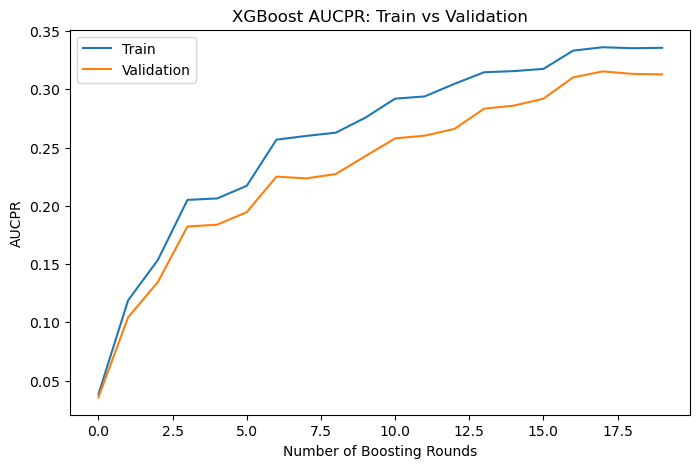

In [47]:
#check for overfit with train vs val aucpr

eval_set = [(train_x, train_y), (val_x, val_y)]
bestmodel.fit(train_x, train_y,
    eval_set=eval_set,
    verbose=True
)

results = bestmodel.evals_result()
epochs = len(results['validation_0']['aucpr'])
x_axis = range(0, epochs)

plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['aucpr'], label='Train')
plt.plot(x_axis, results['validation_1']['aucpr'], label='Validation')
plt.legend()
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('AUCPR')
plt.title('XGBoost AUCPR: Train vs Validation')
plt.show()


In [48]:
# Threshold Moving

pred_val = bestmodel.predict_proba(val_x)[:,1]


cuts = np.linspace(0.01, 0.99, 200)
S_array = np.array([np.sum((val_y==1) & (pred_val>=c)) for c in cuts])
B_array = np.array([np.sum((val_y==0) & (pred_val>=c)) for c in cuts])

mask = (S_array + B_array) >= 50   



fom_array = np.divide(
    S_array,
    np.sqrt(S_array + B_array),
    out=np.zeros_like(S_array, dtype=float),
    where=(S_array + B_array) > 0
)


fom_array_masked = np.where(mask, fom_array, -np.inf)
best_cut = cuts[np.argmax(fom_array_masked)]


print("Best threshold for max significance:", best_cut)

# predict on x_test with cut based on significance: 
pred = bestmodel.predict_proba(x_test)[:, 1]
preds = (pred >= best_cut).astype(int)  # threshold adjusted to significance



Best threshold for max significance: 0.9850753768844221


In [49]:
c = 0.99
print("S@0.99 =", np.sum((val_y==1) & (pred_val>c)))
print("B@0.99 =", np.sum((val_y==0) & (pred_val>c)))
print("S+B@0.99 =", np.sum(pred_val>c))


S@0.99 = 234
B@0.99 = 193
S+B@0.99 = 427


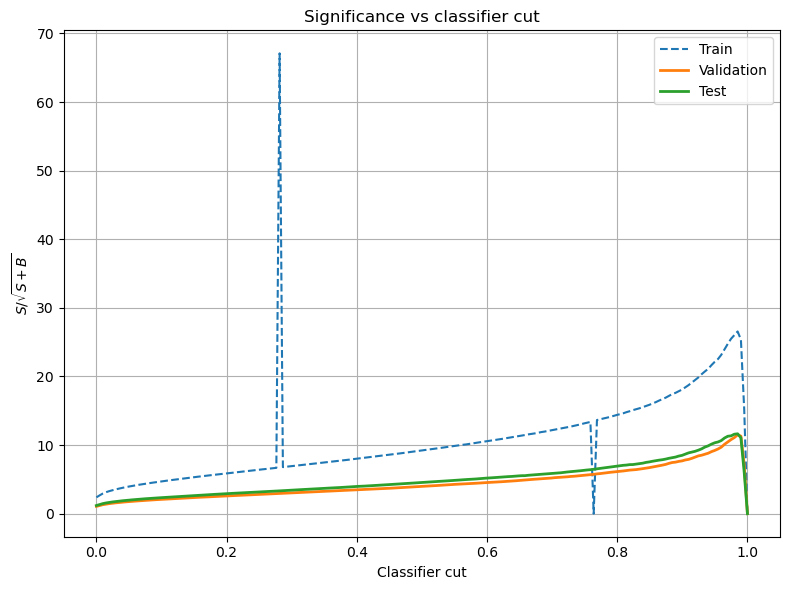

In [50]:
#this is to test for overfitting.

import numpy as np

def significance_curve(y_true, scores, n_cuts=200):
    cuts = np.linspace(0.0, 1.0, n_cuts)
    foms = []

    for c in cuts:
        S = np.sum((y_true == 1) & (scores > c))
        B = np.sum((y_true == 0) & (scores > c))

        if S + B >= 50: #threshold
            foms.append(S / np.sqrt(S + B))
        else:
            foms.append(0.0)

    return cuts, np.array(foms)




# Scores
score_train = bestmodel.predict_proba(x_train_full)[:, 1]
score_val   = bestmodel.predict_proba(val_x)[:, 1]
score_test  = bestmodel.predict_proba(x_test)[:, 1]

cuts_tr, fom_tr = significance_curve(y_train_full, score_train)
cuts_val, fom_val = significance_curve(val_y, score_val)
cuts_te, fom_te = significance_curve(y_test, score_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(cuts_tr, fom_tr, label="Train", linestyle="--")
plt.plot(cuts_val, fom_val, label="Validation", linewidth=2)
plt.plot(cuts_te, fom_te, label="Test", linewidth=2)

plt.xlabel("Classifier cut")
plt.ylabel(r"$S/\sqrt{S+B}$")
plt.title("Significance vs classifier cut")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = preds
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results


#y_proba = bestmodel.predict_proba(x_test)[:,1]
#threshold = 0.54  # experiment with 0.6, 0.65, 0.7
#y_pred_thresh = (y_proba >= threshold).astype(int)

evaluate_results(y_test, preds)

Confusion Matrix:
[[934767    667]
 [   776    378]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935434
         1.0       0.36      0.33      0.34      1154

    accuracy                           1.00    936588
   macro avg       0.68      0.66      0.67    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 34.38%
roc: 66.34%
recall: 32.76%
precision: 36.17%


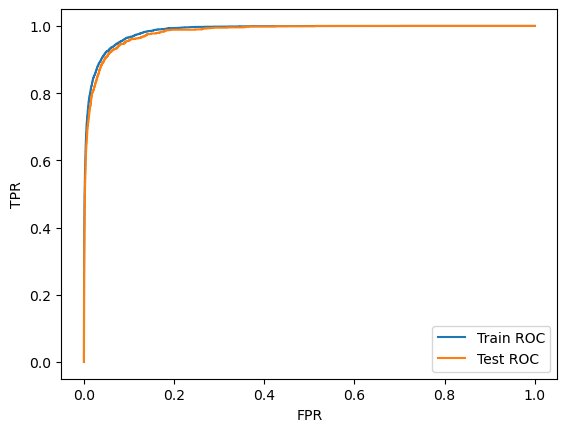

In [52]:
#checking for overfitting with roc

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = bestmodel.predict_proba(x_train_full)[:,1]
y_test_pred  = bestmodel.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train_full, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)

plt.plot(fpr_tr, tpr_tr, label="Train ROC")
plt.plot(fpr_te, tpr_te, label="Test ROC")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


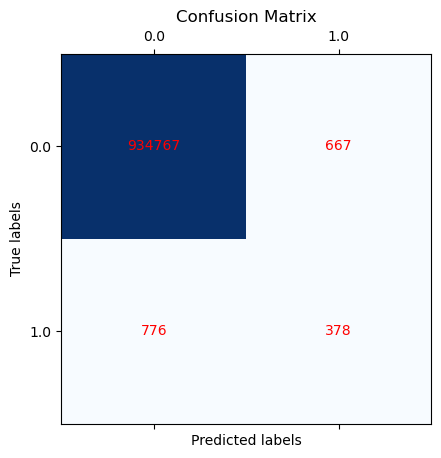

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds)

import numpy as np

labels = np.unique(y_test)

fig, ax = plt.subplots()
im = ax.matshow(cm, cmap=plt.cm.Blues)

# Toon getallen in de cellen
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="red")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()



In [54]:

y_score = bestmodel.predict_proba(x_test)[:, 1] # is without cut

signal_scores = y_score[y_test == 1]
background_scores = y_score[y_test == 0]


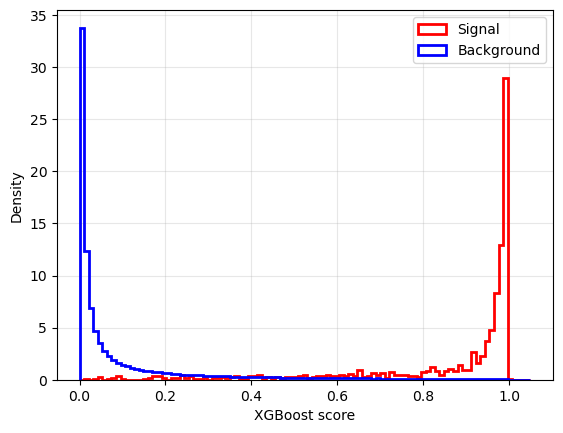

In [55]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1.05, 100)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [56]:


mask = y_score >= best_cut

mass_selected = m_test[mask]


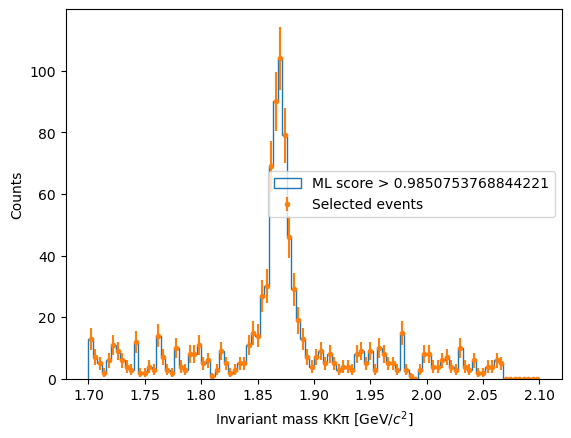

In [57]:
plt.hist(
    mass_selected,
    bins=100,
    range=(1.7, 2.1),
    histtype="step",
    label=f"ML score > {best_cut}"
)

range_mass = (1.7, 2.1)
hist_vals, bin_edges = np.histogram(mass_selected, bins=100, range=range_mass)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
errors = np.sqrt(hist_vals)  # Poisson errors

plt.errorbar(bin_centers, hist_vals, yerr=errors, fmt='.', label='Selected events')
plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.ylabel("Counts")
plt.legend()
plt.show()




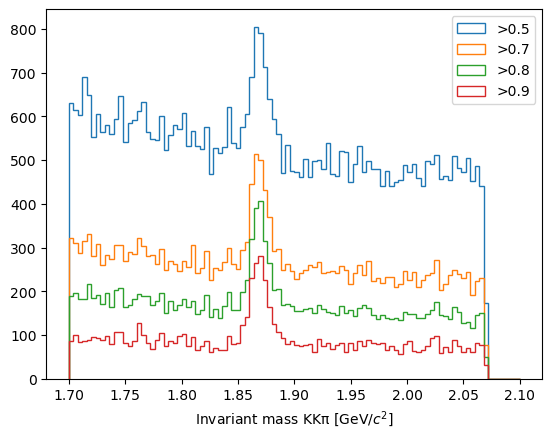

In [58]:
#check with different tresholds if peak is consistent

for cut in [0.5, 0.7, 0.8, 0.9]:
    mask = y_score > cut
    plt.hist(
        m_test[mask],
        bins=100,
        range=(1.7,2.1),
        histtype="step",
        label=f">{cut}"
    )

plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.legend()
plt.show()



In [59]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

def exponential(x, a, b, d):
    return a * np.exp(b * x) + d

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2/(2*sigma**2))

def signal_to_background_from_params(gauss_params, exp_params, k=3):
    a_g, mu_g, sigma_g = gauss_params
    a_e, b_e, d_e = exp_params

    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g
    S, _ = quad(lambda x: gaussian(x, *gauss_params), x_min, x_max)
    B, _ = quad(lambda x: exponential(x, *exp_params), x_min, x_max)
    S_over_B = S / B
    return S, B, S_over_B



# S uncertainty with fit
from scipy.stats import norm

def S_error_from_gauss(popt_gauss, pcov_gauss, k=3):
    """
    Calculate error of signal S = integral(Gauss) ± ΔS
    based on the fit covariance matrix.
    """
    a_g, mu_g, sigma_g = popt_gauss
    cov = pcov_gauss

    # Bounds integration
    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g

    # Afgeleiden van S naar parameters
    # S = a * sigma * sqrt(2*pi) * erf(k/sqrt(2)) ≈ exact numeriek
    # Gebruik numerieke afgeleiden via kleine shift
    delta = 1e-5
    derivs = np.zeros(3)

    # a_g
    S_plus = quad(lambda x: gaussian(x, a_g+delta, mu_g, sigma_g), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g-delta, mu_g, sigma_g), x_min, x_max)[0]
    derivs[0] = (S_plus - S_minus)/(2*delta)

    # mu_g
    S_plus = quad(lambda x: gaussian(x, a_g, mu_g+delta, sigma_g), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g, mu_g-delta, sigma_g), x_min, x_max)[0]
    derivs[1] = (S_plus - S_minus)/(2*delta)

    # sigma_g
    S_plus = quad(lambda x: gaussian(x, a_g, mu_g, sigma_g+delta), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g, mu_g, sigma_g-delta), x_min, x_max)[0]
    derivs[2] = (S_plus - S_minus)/(2*delta)

    # Propagate errors
    S_err = np.sqrt(derivs @ cov @ derivs.T)
    return S_err


def bump_hunt(candidates, signal_window=(1.84, 1.89)): #1.85, 1.9

    # Histogram

    #hist, bin_edges = np.histogram(candidates, bins, range=(np.min(candidates), np.max(candidates)))

    sigma_guess = 0.008 # pas aan aan je signaal
    bin_width = sigma_guess 
    x_min, x_max = min(candidates), max(candidates)
    N_bins = int(np.ceil((x_max - x_min) / bin_width))
    hist, bin_edges = np.histogram(candidates, bins=N_bins, range=(x_min, x_max))
    

    bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


    # Exclude signal window for background fit
    mask = (bin_centers < signal_window[0]) | (bin_centers > signal_window[1])
    hist_bkg, bins_bkg = hist[mask], bin_centers[mask]

   

    # Fit exponential
    popt_exp, pcov_exp = curve_fit(exponential, bins_bkg, hist_bkg, p0=(max(hist_bkg), -1, min(hist_bkg)),maxfev=35000)

    # Fit Gaussian + exponential
    def gauss_plus_exp(x, a_g, mu_g, sigma_g):
        return gaussian(x, a_g, mu_g, sigma_g) + exponential(x, *popt_exp)
    

    
    popt_gauss, pcov_gauss = curve_fit(gauss_plus_exp, bin_centers, hist, p0=(max(hist)-min(hist), 1.869, sigma_guess),maxfev=35000)
    S, B, S_over_B = signal_to_background_from_params(popt_gauss, popt_exp)
    sigma_params = np.sqrt(np.diag(pcov_gauss))  # [Δa_g, Δmu_g, Δsigma_g]

    mu, sigma = popt_gauss[1] * 1000, popt_gauss[2] * 1000  #MeV/c2
    dmu, dsigma = sigma_params[1] * 1000, sigma_params[2] * 1000  #MeV/c2

    S_err = S_error_from_gauss(popt_gauss, pcov_gauss, k=3)
    


    # Plot
    x_fit = np.linspace(1.7, 2.1, 500)
    plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist), fmt='.', label='Data')
    plt.plot(x_fit, gauss_plus_exp(x_fit, *popt_gauss), label='Gaussian + Exp fit', color='green')
    plt.plot(x_fit, exponential(x_fit, *popt_exp), '--', label='Background', color='red')
   # plt.plot(x_fit, gaussian(x_fit, *popt_gauss), ':', label='Gaussian', color='blue')
    plt.text(1.91, max(hist)*0.55,
          f"μ = {mu:.3f} ± {dmu:.3f} MeV/c²\n"
          f"σ = {sigma:.3f} ± {dsigma:.3f} MeV/c²\n"
        
          f"S = {S:.0f} ± {S_err:.0f}\n"
          f"B = {B:.0f}\n"
          f"S/B (3σ) = {S_over_B:.2f}",
          bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('$M$(KKπ) [GeV/c²]')
    plt.ylabel('Counts per 8 MeV/c²')
    plt.legend()
    plt.show()

    # Compute S/B
    
    
#    print("Masked bins outside signal window:")
#    for x, m in zip(bin_centers, mask):
 #       if m:
   #         print(f"{x:.3f}")

    return popt_exp, popt_gauss, S, B, S_over_B


# Voer de functie uit en pak alleen N_bins



In [60]:
print("Number of events in mass_selected:", len(mass_selected))
print("Min mass:", np.min(mass_selected))
print("Max mass:", np.max(mass_selected))
print("First 10 masses:", mass_selected[:10])


Number of events in mass_selected: 1045
Min mass: 1.6700014
Max mass: 2.0679896
First 10 masses: [2.010507  1.8513054 1.8581338 1.9072766 1.8819603 1.8719813 1.8778393
 1.8894352 1.8668362 1.8558152]


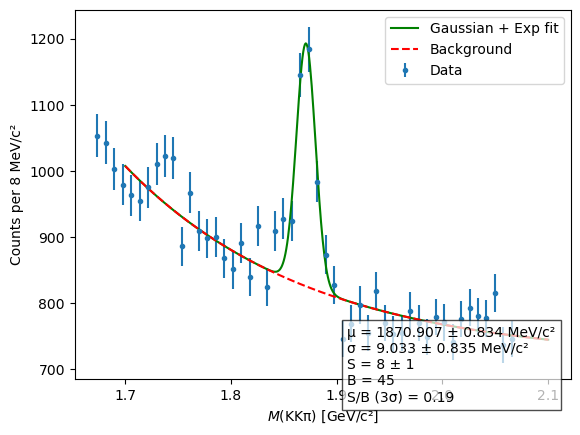

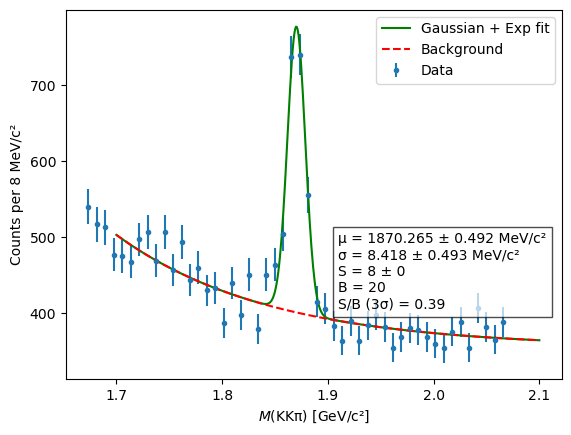

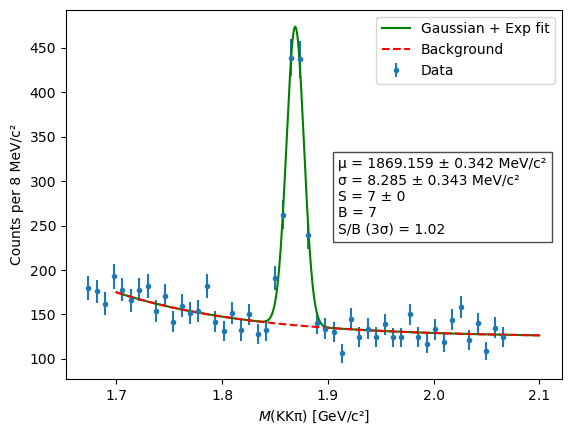

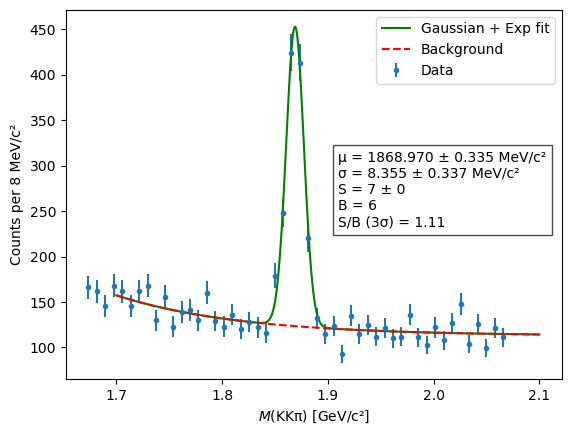

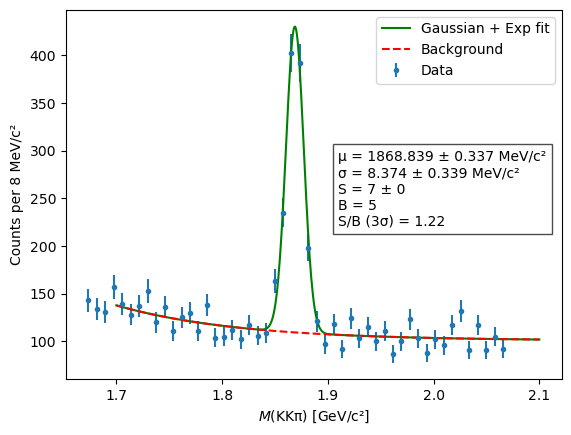

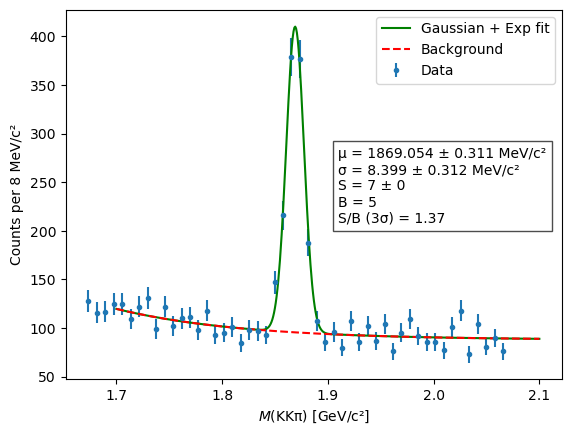

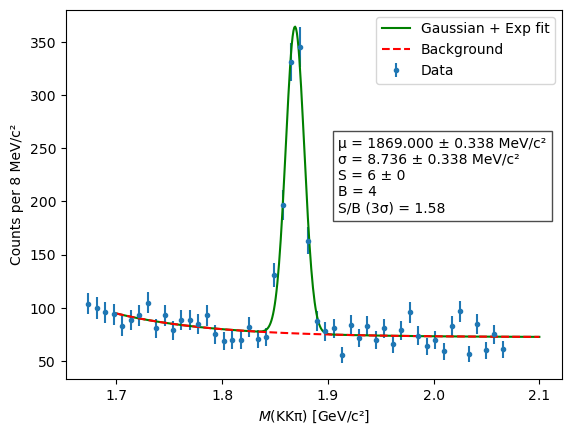

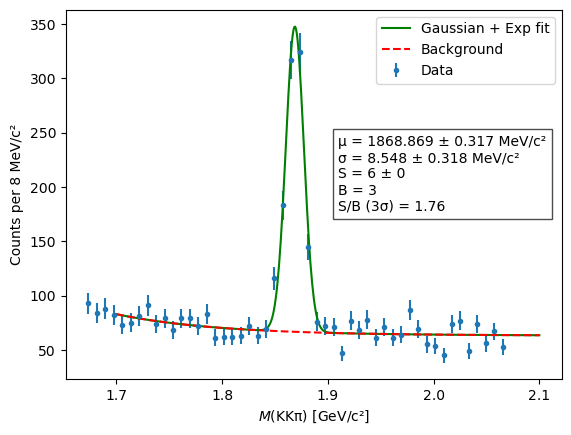

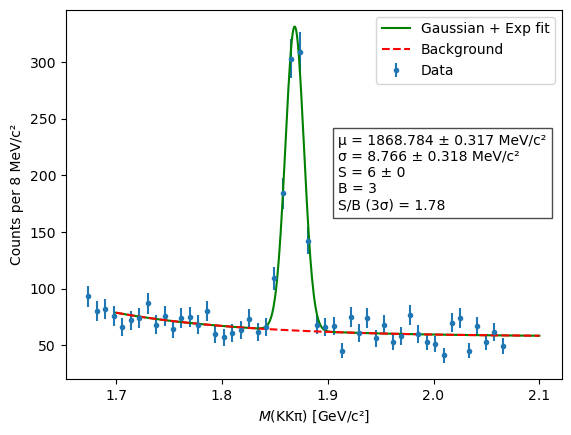

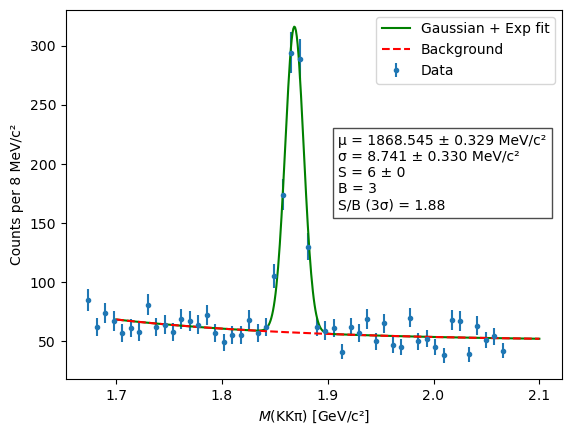

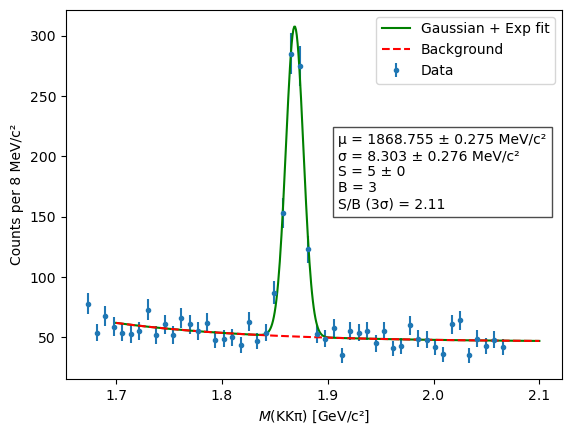

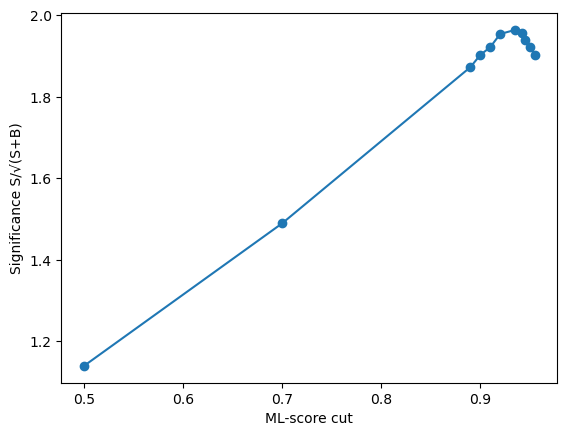

Best ML-score cut from validation set: 0.935


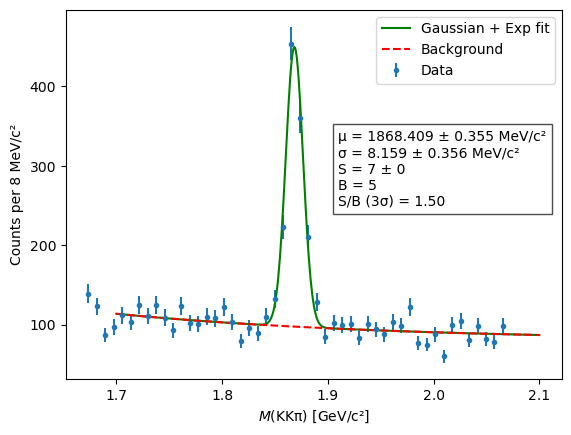

Test set significance: 2.076512403555568
S/B: 1.5026943118184801


In [61]:
#test cuts based on the validation set

cuts = [0.5, 0.7, 0.89, 0.9, 0.91, 0.92, 0.935, 0.942, 0.945, 0.95, 0.955]
significances = []


score_val   = bestmodel.predict_proba(val_x)[:, 1]


for cut in cuts:
    mask = score_val > cut
    mass_selected = m_val[mask]
    _, _, S, B, _ = bump_hunt(mass_selected)
    sig = S / np.sqrt(S+B)
    significances.append(sig)

plt.plot(cuts, significances, marker='o')
plt.xlabel("ML-score cut")
plt.ylabel("Significance S/√(S+B)")
plt.show()



# pick best cut
best_cut = cuts[np.argmax(significances)]
print("Best ML-score cut from validation set:", best_cut)

# apply cut to test set
score_test = bestmodel.predict_proba(x_test)[:, 1]
mask_test = score_test > best_cut
mass_selected_test = m_test[mask_test]

popt_exp, popt_gauss, S, B, S_over_B = bump_hunt(mass_selected_test, signal_window=(1.84, 1.89))
significance = S / np.sqrt(S + B)
print("Test set significance:", significance)
print("S/B:", S_over_B)